G.N. Savin's *Stress Distribution Around Holes* is a classic application of the **Kolosov-Muskhelishvili complex variable method**. This method reduces complex elasticity problems to finding two analytic functions,  and .

Because the entire book relies on complex analysis and conformal mapping, the best programming language for this learning path is **Python**.

**Why Python?**

* **Native Complex Support:** Python has complex numbers as a primitive data type (e.g., `z = 3 + 4j`). You can perform arithmetic directly on them without special classes.
* **Visualization:** Libraries like `matplotlib` allow you to easily plot stress contours (isochromatics) on complex planes.
* **Symbolic Math:** The `sympy` library can help derive the derivatives of complex potentials symbolically before you calculate them numerically.

---

### **Learning Path: Computational Elasticity with Savin**

This path moves from the basic isotropic solutions to complex shapes using conformal mapping, and finally to anisotropic plates.

#### **Phase 1: The Mathematical Engine (Chapter I)**

**Goal:** Build a reusable code structure to calculate stresses from potentials.

* **Theory:**
* Understand the Kolosov-Muskhelishvili formulas (Eq. I.13 in the text).
*
*


* **Coding Task:**
* Write a Python function `calculate_stress(phi_prime, psi, z)` that takes complex potentials and coordinates and returns the stress tensor components .



#### **Phase 2: The Circular Hole (Chapter II, §1-2)**

**Goal:** Replicate the classic Kirsch solution using Savin's complex formulation.

* **Theory:**
* Study the potentials for a circular hole under uniaxial tension (Eq. II.19 in the text).
*
*  (Note: These forms vary slightly based on boundary conditions).


* **Coding Task:**
* Define the domain as a grid of complex numbers  (excluding the hole).
* Compute the stresses using the function from Phase 1.
* Plot the **Stress Concentration Factor (SCF)** along the hole edge () and verify it peaks at .



#### **Phase 3: Conformal Mapping & Shapes (Chapter II, §2)**

**Goal:** Solve for Ellipses, Squares, and Triangles.

* **Theory:**
* Learn how to map the exterior of a unit circle () to the exterior of a physical hole () using mapping functions .
* Example: Ellipse .


* **Coding Task:**
* Implement the chain rule for derivatives in your code:

* **Project:** Recreate the stress distribution for the "Square Hole with Rounded Corners" (Figure II.2 in the book) using the series expansion mapping.



#### **Phase 4: Anisotropic Plates (Chapter III)**

**Goal:** Introduce material directionality (e.g., wood, composites).

* **Theory:**
* Learn the affine transformation method.
* Understand the complex parameters  and  (roots of the characteristic equation).


* **Coding Task:**
* Modify your stress calculator to handle the generalized complex variables  and .
* Calculate the SCF for a circular hole in an orthotropic plate (e.g., Plywood) and compare it to the isotropic .



---

### **Getting Started: The Python Setup**

Here is a Python script to start **Phase 1 and 2**. It sets up the stress calculation engine and solves the basic circular hole problem.

You can run this directly if you have Python installed (`pip install numpy matplotlib`).

C:\Users\Usuario\AppData\Local\Temp\ipykernel_34948\2143577774.py:37: RuntimeWarning: invalid value encountered in divide
  d_phi = (p / 4) * (1 - 2 * (R**2) / (z_grid**2))
C:\Users\Usuario\AppData\Local\Temp\ipykernel_34948\2143577774.py:38: RuntimeWarning: invalid value encountered in divide
  d_psi = -(p / 2) * (1 - (R**2) / (z_grid**2) + 3 * (R**4) / (z_grid**4))
C:\Users\Usuario\AppData\Local\Temp\ipykernel_34948\2143577774.py:45: RuntimeWarning: invalid value encountered in divide
  dd_phi = (p / 4) * (4 * (R**2) / (z_grid**3)) # Derivative of Phi


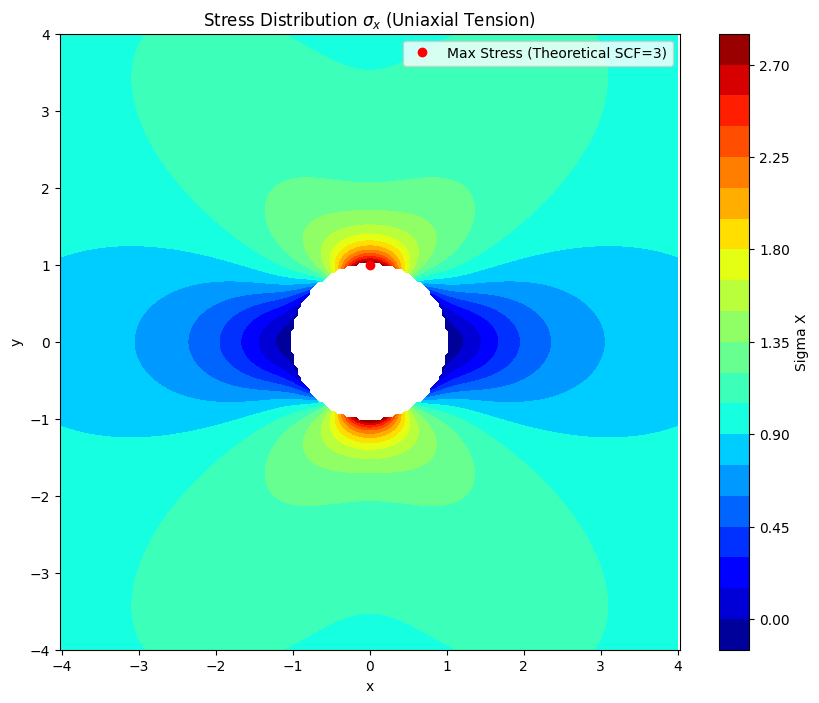

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_stress_field(z_grid, p_load, radius):
    """
    Calculates stresses around a circular hole under uniaxial tension 'p_load'
    using Savin's complex potential formulation.
    """
    # 1. Define the complex potentials phi(z) and psi(z)
    # Note: These derivatives are based on the standard solution for a hole
    # derived from Savin's Chapter II.

    # Term 1: Uniform tension at infinity
    # Term 2: Effect of the hole

    # To compute stresses, we need Phi(z) = phi'(z) and Psi(z) = psi'(z)
    # R = radius, p = tension
    R = radius
    p = p_load

    # Explicitly handle division by zero at the origin.
    z_grid[z_grid == 0] = np.nan

    # Psi(z) = p/2 * (1 - (R**2)/(z_grid**2) + 3*(R**4)/(z_grid**4)) - this is actually Upper Psi
    # The standard form for stresses uses Psi(z) = psi'(z).
    # For uniaxial tension: Psi(z) = -p/2 * (1 - 3*R^2/z^2 + 3*R^4/z^4) (Check specific sign convention in Savin)

    # Let's use the explicit stress formulas derived from the potentials (Kirsch solution)
    # which is often safer to implement directly to avoid branch cut issues in raw potentials early on.
    # However, to stick to the "Potential Method":

    # Re-defining potentials purely as functions of z:
    # phi(z) = p/4 * (z + 2*R^2/z)
    # psi(z) = -p/2 * (z + R^2/z - R^4/z^3)  <-- Common form

    # Derivatives:
    d_phi = (p / 4) * (1 - 2 * (R**2) / (z_grid**2))
    d_psi = -(p / 2) * (1 - (R**2) / (z_grid**2) + 3 * (R**4) / (z_grid**4))

    # 2. Apply Kolosov-Muskhelishvili Equations (Savin Eq I.13)
    # sigma_x + sigma_y = 4 * Re(Phi)
    # sigma_y - sigma_x + 2*i*tau_xy = 2 * (z_bar * Phi' + Psi)
    # Note: We need Phi' (second derivative of phi) for the second equation.

    dd_phi = (p / 4) * (4 * (R**2) / (z_grid**3)) # Derivative of Phi

    # Calculation
    # Sum of stresses
    sigma_sum = 4 * np.real(d_phi)

    # Difference of stresses
    z_bar = np.conjugate(z_grid)
    sigma_diff_complex = 2 * (z_bar * dd_phi + d_psi)

    # Extract components
    sigma_y_minus_x = np.real(sigma_diff_complex)
    tau_xy_2 = np.imag(sigma_diff_complex)

    sigma_x = (sigma_sum - sigma_y_minus_x) / 2
    sigma_y = (sigma_sum + sigma_y_minus_x) / 2
    tau_xy = tau_xy_2 / 2

    return sigma_x, sigma_y, tau_xy

# --- Setup the Grid ---
R = 1.0  # Radius of hole
L = 4.0  # Size of plate (half-width)
points = 200

x = np.linspace(-L, L, points)
y = np.linspace(-L, L, points)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

# Mask the hole (set values inside radius to NaN)
mask = np.abs(Z) < R
Z[mask] = np.nan

# --- Calculate ---
# Tension p=1.0 along x-axis
sx, sy, txy = calculate_stress_field(Z, 1.0, R)

# --- Visualize ---
plt.figure(figsize=(10, 8))
# Plot Sigma_x (Stress in pulling direction)
contour = plt.contourf(X, Y, sx, levels=20, cmap='jet')
plt.colorbar(contour, label='Sigma X')
plt.title(f'Stress Distribution $\\sigma_x$ (Uniaxial Tension)')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')

# Mark the theoretical max stress point
# At top of hole (x=0, y=R), Sigma_x should be 3.0 (SCF = 3)
plt.plot(0, R, 'ro', label='Max Stress (Theoretical SCF=3)')
plt.legend()
plt.show()




**Next Step:**
Would you like to try running this to verify the  concentration factor, or should we move immediately to **Chapter II §2** to implement the conformal mapping for the **Square Hole**?